<a href="https://colab.research.google.com/github/jaxpacleb/Sentiment-Analysis-NLP/blob/main/Sentiment_Analysis_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data...
Fitting tokenizer...
Processing Bag-of-Words (Binary)...
Processing TF-IDF...

Training BoW Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 - 3s - 81ms/step - accuracy: 0.6344 - loss: 0.6419 - val_accuracy: 0.8476 - val_loss: 0.5343
Epoch 2/10
40/40 - 2s - 39ms/step - accuracy: 0.7563 - loss: 0.5282 - val_accuracy: 0.8786 - val_loss: 0.4202
Epoch 3/10
40/40 - 1s - 28ms/step - accuracy: 0.8163 - loss: 0.4390 - val_accuracy: 0.8846 - val_loss: 0.3370
Epoch 4/10
40/40 - 1s - 31ms/step - accuracy: 0.8535 - loss: 0.3750 - val_accuracy: 0.8870 - val_loss: 0.3004
Epoch 5/10
40/40 - 1s - 31ms/step - accuracy: 0.8843 - loss: 0.3235 - val_accuracy: 0.8920 - val_loss: 0.2793
Epoch 6/10
40/40 - 2s - 41ms/step - accuracy: 0.9036 - loss: 0.2850 - val_accuracy: 0.8920 - val_loss: 0.2718
Epoch 7/10
40/40 - 2s - 47ms/step - accuracy: 0.9164 - loss: 0.2545 - val_accuracy: 0.8918 - val_loss: 0.2766
Epoch 8/10
40/40 - 1s - 35ms/step - accuracy: 0.9253 - loss: 0.2299 - val_accuracy: 0.8950 - val_loss: 0.2822
Epoch 9/10
40/40 - 1s - 28ms/step - accuracy: 0.9346 - loss: 0.2096 - val_accuracy: 0.8950 - val_loss: 0.2977
Epoch 10/1

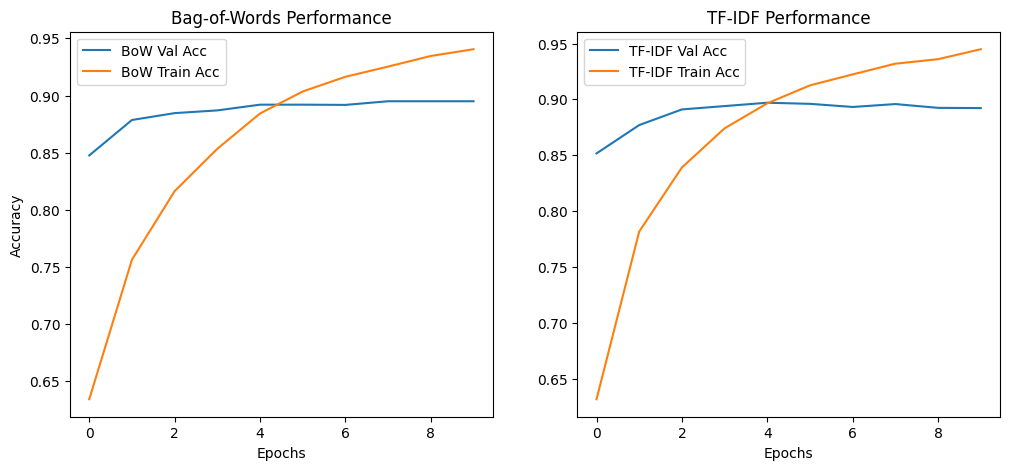

In [ ]:
#MEMBERS: GERMIN P. PACLEB - DANIEL EDISON GANADO - RICHARD SCOTT RICOHERMOSO - SEBASTIAN KIRT C DOCTOR
#TIME SERIES FORECASTING WITH LSTM
#SECTION: BSCS 3B


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras import models, layers

# 1. PARAMETERS
VOCAB_SIZE = 10000

# 2. LOAD DATA
print("Loading data...")
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=VOCAB_SIZE)

# 3. FEATURE EXTRACTION
tokenizer = Tokenizer(num_words=VOCAB_SIZE)

# --- THE FIX IS HERE ---
# We must "fit" the tokenizer on the training data so it learns
# the document frequency (IDF) for every word.
print("Fitting tokenizer...")
tokenizer.fit_on_sequences(train_data)
# -----------------------

def prepare_data(sequences, mode):
    # sequences_to_matrix creates a (samples x VOCAB_SIZE) matrix
    return tokenizer.sequences_to_matrix(sequences, mode=mode)

# --- APPROACH A: BAG OF WORDS (BINARY) ---
print("Processing Bag-of-Words (Binary)...")
x_train_bow = prepare_data(train_data, mode='binary')
x_test_bow = prepare_data(test_data, mode='binary')

# --- APPROACH B: TF-IDF ---
print("Processing TF-IDF...")
# This will now work because the tokenizer has been fit
x_train_tfidf = prepare_data(train_data, mode='tfidf')
x_test_tfidf = prepare_data(test_data, mode='tfidf')

# 4. DEFINE MODEL ARCHITECTURE
def build_model():
    model = models.Sequential([
        layers.Dense(16, activation='relu', input_shape=(VOCAB_SIZE,)),
        layers.Dropout(0.5),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 5. TRAIN AND EVALUATE: BAG OF WORDS
print("\nTraining BoW Model...")
model_bow = build_model()
history_bow = model_bow.fit(x_train_bow, train_labels,
                            epochs=10,
                            batch_size=512,
                            validation_split=0.2,
                            verbose=2) # Set verbose=2 to see progress

# 6. TRAIN AND EVALUATE: TF-IDF
print("\nTraining TF-IDF Model...")
model_tfidf = build_model()
history_tfidf = model_tfidf.fit(x_train_tfidf, train_labels,
                                epochs=10,
                                batch_size=512,
                                validation_split=0.2,
                                verbose=2)

# 7. VISUALIZATION
plt.figure(figsize=(12, 5))

# Plot BoW
plt.subplot(1, 2, 1)
plt.plot(history_bow.history['val_accuracy'], label='BoW Val Acc')
plt.plot(history_bow.history['accuracy'], label='BoW Train Acc')
plt.title('Bag-of-Words Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot TF-IDF
plt.subplot(1, 2, 2)
plt.plot(history_tfidf.history['val_accuracy'], label='TF-IDF Val Acc')
plt.plot(history_tfidf.history['accuracy'], label='TF-IDF Train Acc')
plt.title('TF-IDF Performance')
plt.xlabel('Epochs')
plt.legend()

plt.show()

In [ ]:
#